# **Chú thích**
**Muc đích của file này là huấn luyện, thử nghiệm và so sánh 3 mô hình CF.**

- User-based
- Item-based
- ALS

# **1. DỮ LIỆU VÀ THIẾT LẬP**

## **1.1. IMPORT**

In [ ]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for implicit: filename=implicit-0.7.2-cp312-cp312-linux_x86_64.whl size=933265 sha256=0f7907a44a293fcf605bf769d9640d6bd80780d5e8430630eeada772544f0252
  Stored in directory: /root/.cache/pip/wheels/b2/00/4f/9ff8af07a0a53ac6007ea5d739da19cfe147a2df542b6899f8
Successfully built implicit


In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import pickle
from implicit.als import AlternatingLeastSquares

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **1.2. SETTING**

In [ ]:
TEST_RATIO = 0.2          # train/test = 8/2

TOPK_REC = 10
TOPK_SIM = 30

BATCH_SIZE = 500
MAX_USERS = 3000

ALS_FACTORS = 256
ALS_ITERATIONS = 30
ALS_REG = 0.02
ALS_ALPHA = 30

MODEL_ITEM_PATH = "item_cf_model.pkl"
MODEL_USER_PATH = "user_cf_model.pkl"
MODEL_ALS_PATH = "als_model.pkl"

RANDOM_STATE = 42

In [ ]:
np.random.seed(RANDOM_STATE)

## **1.3. LOAD DATA**

In [ ]:
interactions = pd.read_csv(
    "/content/drive/MyDrive/datasets/data_lyrics.csv",
    usecols=['user_id', 'track_id', 'play_count', 'rating']
)

metadata = pd.read_csv(
    "/content/drive/MyDrive/datasets/metadata.csv",
    usecols=['track_id', 'artist_name', 'title']
)

In [ ]:
interactions.shape

(1885932, 4)

In [ ]:
interactions.head()

,user_id,play_count,rating,track_id
0,5a905f000fc1ff3df7ca807d57edb608863db05d,1,0.693147,TRCWHIO128F1488FB7
1,5a905f000fc1ff3df7ca807d57edb608863db05d,1,0.693147,TRFNWEZ128F1452603
2,5a905f000fc1ff3df7ca807d57edb608863db05d,1,0.693147,TRWZXDS128F427A71B
3,5a905f000fc1ff3df7ca807d57edb608863db05d,1,0.693147,TRMMKJX128E07818C1
4,5a905f000fc1ff3df7ca807d57edb608863db05d,2,1.098612,TRKNKEF128F425FD6A


In [ ]:
metadata.shape

(999039, 3)

In [ ]:
metadata.head()

,track_id,artist_name,title
0,TRMMMYQ128F932D901,Faster Pussy cat,Silent Night
1,TRMMMKD128F425225D,Karkkiautomaatti,Tanssi vaan
2,TRMMMRX128F93187D9,Hudson Mohawke,No One Could Ever
3,TRMMMCH128F425532C,Yerba Brava,Si Vos Querés
4,TRMMMWA128F426B589,Der Mystic,Tangle Of Aspens


## **1.4. CHIA TRAIN / TEST**

In [ ]:
def train_test_split_by_user(df, test_ratio=0.2, random_state=42):
    np.random.seed(random_state)

    train_indices = []
    test_indices = []

    for user_id, group in tqdm(df.groupby('user_id'), desc="Split train/test"):
        group_indices = group.index.values  # Lấy indices của group

        if len(group_indices) < 2:
            train_indices.extend(group_indices)  # Đẩy hết vào train
            continue

        test_size = max(1, int(len(group_indices) * test_ratio))
        # Random chọn test indices
        test_idx = np.random.choice(group_indices, size=test_size, replace=False)

        # Các indices còn lại vào train
        train_idx = np.setdiff1d(group_indices, test_idx)

        train_indices.extend(train_idx)
        test_indices.extend(test_idx)

    # Chỉ loc một lần duy nhất → nhẹ RAM
    train_df = df.loc[train_indices].reset_index(drop=True)
    test_df = df.loc[test_indices].reset_index(drop=True)

    print(f"Train interactions: {len(train_df)}")
    print(f"Test interactions: {len(test_df)}")
    print(f"Total: {len(train_df) + len(test_df)} (giữ nguyên {len(df)} ban đầu)")

    return train_df, test_df

In [ ]:
train_df, test_df = train_test_split_by_user(interactions)

Split train/test: 100%|██████████| 19903/19903 [00:03<00:00, 5671.30it/s]


Train interactions: 1516735
Test interactions: 369197
Total: 1885932 (giữ nguyên 1885932 ban đầu)


In [ ]:
train_df = pd.read_csv(
    "/content/drive/MyDrive/datasets/data_train.csv")

test_df = pd.read_csv(
    "/content/drive/MyDrive/datasets/data_test.csv")

## **1.5. HIỂN THỊ KẾT QUẢ METADATA**

In [ ]:
def show_result(user_history_df, rec_data):
    # listened (giữ nguyên)
    listened = (
        user_history_df[['track_id']]
        .merge(metadata, on='track_id', how='left')
        .fillna({"title": "Unknown", "artist_name": "Unknown"})
    )

    # rec_data giờ là tuple (rec_ids, rec_scores)
    rec_ids, rec_scores = rec_data

    rec_df = pd.DataFrame({
        "track_id": rec_ids,
        "score": [f"{s:.4f}" for s in rec_scores]  # format đẹp 4 chữ số
    })

    recommended = (
        rec_df
        .merge(metadata, on='track_id', how='left')
        .fillna({"title": "Unknown", "artist_name": "Unknown"})
    )

    # Thêm rank
    recommended.insert(0, 'rank', range(1, len(recommended) + 1))

    return listened, recommended

## **1.6. Hàm đánh giá điểm số**

In [ ]:
def precision_at_k(rec, gt, k):
    return len(set(rec[:k]) & set(gt)) / k

def recall_at_k(rec, gt):
    return len(set(rec) & set(gt)) / len(gt)

def average_precision(rec, gt):
    hits, score = 0, 0
    for i, r in enumerate(rec):
        if r in gt:
            hits += 1
            score += hits / (i+1)
    return score / len(gt) if gt else 0

def ndcg_at_k(rec, gt, k):
    if not gt:
        return 0.0

    dcg = 0.0
    for i, item in enumerate(rec[:k]):
        if item in gt:
            dcg += 1 / np.log2(i + 2)

    # ideal DCG
    ideal_hits = min(len(gt), k)
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))

    return dcg / idcg if idcg > 0 else 0.0

## **1.7. LƯU MODEL**

In [ ]:
def save_model(model, filename):

    # Đường dẫn đầy đủ trên Drive
    save_dir = "/content/drive/MyDrive/models"
    save_path = os.path.join(save_dir, filename)

    # Tạo thư mục nếu chưa tồn tại
    os.makedirs(save_dir, exist_ok=True)

    # Lưu model bằng pickle
    with open(save_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Đã lưu model thành công tại: {save_path}")

## **1.8. LOAD MODEL**

In [ ]:
def load_model(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# **2. ITEM-BASED CF TRADITIONAL**

## **2.1. TRAIN ITEM-BASED CF**

In [ ]:
def train_item_cf(train_df, topk=TOPK_SIM, batch_size=BATCH_SIZE):
    users = train_df.user_id.unique()
    songs = train_df.track_id.unique()

    user2idx = {u: i for i, u in enumerate(users)}
    song2idx = {s: i for i, s in enumerate(songs)}
    idx2song = {i: s for s, i in song2idx.items()}

    # User-Item Matrix
    matrix = csr_matrix((
        train_df.rating,
        (
            train_df.user_id.map(user2idx),
            train_df.track_id.map(song2idx)
        )
    ))

    # TF-IDF + normalize
    tfidf = TfidfTransformer(norm=None)
    matrix_tfidf = tfidf.fit_transform(matrix)
    matrix_tfidf = normalize(matrix_tfidf, axis=0)

    n_items = matrix.shape[1]
    rows, cols, vals = [], [], []

    # Item-Item similarity
    for i in tqdm(range(0, n_items, batch_size), desc="Item CF training"):
        sims = cosine_similarity(
            matrix_tfidf.T[i:i+batch_size],
            matrix_tfidf.T
        )

        for idx, sim_row in enumerate(sims):
            item_idx = i + idx
            top_items = np.argsort(sim_row)[-topk-1:-1]

            for j in top_items:
                rows.append(item_idx)
                cols.append(j)
                vals.append(sim_row[j])

    item_similarity = csr_matrix(
        (vals, (rows, cols)),
        shape=(n_items, n_items)
    )

    return {
        "item_similarity": item_similarity,
        "song2idx": song2idx,
        "idx2song": idx2song
    }


## **2.2. HÀM RECOMMEND**

In [ ]:
def recommend_item_cf(user_history_df, model, topK=TOPK_REC):
    song2idx = model['song2idx']
    idx2song = model['idx2song']
    sim = model['item_similarity']

    user_vector = np.zeros(len(song2idx))
    listened_idx = []

    for _, r in user_history_df.iterrows():
        if r.track_id in song2idx:
            idx = song2idx[r.track_id]
            user_vector[idx] = r.rating
            listened_idx.append(idx)

    scores = user_vector @ sim
    scores[listened_idx] = -np.inf

    top_idx = np.argsort(scores)[-topK:][::-1]
    top_scores = scores[top_idx]

    rec_ids = [idx2song[i] for i in top_idx]

    return rec_ids, top_scores

## **2.3. ĐÁNH GIÁ MÔ HÌNH**

In [ ]:
def evaluate_item_cf(train_df, test_df, model, k=TOPK_REC, max_users=MAX_USERS):
    P, R, AP, NDCG, F1, HR = [], [], [], [], [], []

    all_test_users = test_df.user_id.unique()
    effective_max_users = min(max_users, len(all_test_users))

    users = np.random.choice(all_test_users, size=effective_max_users, replace=False)

    for user in tqdm(users, desc="Evaluating Item-based CF"):
        gt = test_df[test_df.user_id == user].track_id.tolist()
        hist = train_df[train_df.user_id == user][['track_id', 'rating']]
        if hist.empty:
            continue

        rec_ids, _ = recommend_item_cf(hist, model, topK=k)
        rec = rec_ids

        p = precision_at_k(rec, gt, k)
        r = recall_at_k(rec, gt)
        P.append(p)
        R.append(r)
        AP.append(average_precision(rec, gt))
        NDCG.append(ndcg_at_k(rec, gt, k))

        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
        F1.append(f1)

        hit = 1 if len(set(rec[:k]) & set(gt)) > 0 else 0
        HR.append(hit)

    return {
        "Precision@K": np.mean(P),
        "Recall@K": np.mean(R),
        "MAP": np.mean(AP),
        "NDCG@K": np.mean(NDCG),
        "F1@K": np.mean(F1),
        "Hit Rate@K": np.mean(HR)
    }

## **2.4. MAIN**

In [ ]:
if __name__ == "__main__":

    model = train_item_cf(train_df)
    save_model(model, MODEL_ITEM_PATH)

    metrics_item_cf = evaluate_item_cf(train_df, test_df, model)
    print(metrics_item_cf)

    print("\n=== ITEM-BASED ===\n")
    user = train_df.user_id.iloc[0]
    full_history = train_df[train_df.user_id == user][['track_id', 'rating']]
    hist = full_history.sample(n=5, random_state=42).reset_index(drop=True)

    # Recommend
    rec_ids, rec_scores = recommend_item_cf(hist, model, topK=10)

    listened, recommended = show_result(hist, (rec_ids, rec_scores))

    print("\n=== INPUT ===")
    print(listened[['title', 'artist_name']].to_string(index=False))

    print("\n=== RECOMMENDED ===")
    print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

Item CF training: 100%|██████████| 23/23 [00:12<00:00,  1.77it/s]


Đã lưu model thành công tại: /content/drive/MyDrive/models/item_cf_model.pkl


Evaluating: 100%|██████████| 3000/3000 [09:59<00:00,  5.00it/s]


{'Precision@K': np.float64(0.2235), 'Recall@K': np.float64(0.13135804100275117), 'MAP': np.float64(0.08761489148550163), 'NDCG@K': np.float64(0.2630344754320354)}

=== ITEM-BASED ===


=== INPUT ===
                 title     artist_name
Crepuscule With Nellie Thelonious Monk
                  Side          Travis
   Siempre Es De Noche  Alejandro Sanz
                  Just       Radiohead
           Voto Latino         Molotov

=== RECOMMENDED ===
 rank                   title artist_name  score
    1                   Bones   Radiohead 0.8628
    2                    Sulk   Radiohead 0.7517
    3              Black Star   Radiohead 0.6906
    4            Planet Telex   Radiohead 0.6884
    5                Let Down   Radiohead 0.6676
    6          Talk Show Host   Radiohead 0.6570
    7                 Ripcord   Radiohead 0.6550
    8                     You   Radiohead 0.6492
    9            Karma Police   Radiohead 0.6457
   10 Exit Music (For A Film)   Radiohead 0.6446


## **2.5. TÁI SỬ DỤNG MODEL**

In [ ]:
model_item_cf = load_model("/content/drive/MyDrive/models/item_cf_model.pkl")
print("Model loaded!")

Model loaded!


In [ ]:
metrics_item_cf = evaluate_item_cf(train_df, test_df, model_item_cf)
print(metrics_item_cf)

print("\n=== ITEM-BASED ===\n")
user = train_df.user_id.iloc[0]
full_history = train_df[train_df.user_id == user][['track_id', 'rating']]
hist = full_history.sample(n=5, random_state=42).reset_index(drop=True)

# Recommend
rec_ids, rec_scores = recommend_item_cf(full_history, model_item_cf, topK=10)

listened, recommended = show_result(full_history, (rec_ids, rec_scores))

print("\n=== INPUT ===")
print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

Evaluating Item-based CF: 100%|██████████| 3000/3000 [09:57<00:00,  5.02it/s]


{'Precision@K': np.float64(0.2164333333333333), 'Recall@K': np.float64(0.12962660759963263), 'MAP': np.float64(0.08674541974737629), 'NDCG@K': np.float64(0.25722352148245164), 'F1@K': np.float64(0.153495676831521), 'Hit Rate@K': np.float64(0.768)}

=== ITEM-BASED ===


=== INPUT ===
                                                title        artist_name
                                                 Just          Radiohead
                                 Don't Cry (Original)      Guns N' Roses
                                             Uprising               Muse
                                         Losing Touch        The Killers
                               Crepuscule With Nellie    Thelonious Monk
                                           Invincible               Muse
                                       Prince Caspian              Phish
            Colgando en tus manos (con Marta Sanchez)       Carlos Baute
                                                Bliss      

In [ ]:
print("=== ITEM-BASED CF ===\n")
# Chọn 1 user cũ bất kỳ (có trong train_df và model)
user_id = train_df.user_id.unique()[20]
print("User ID:", user_id)

# Lấy toàn bộ lịch sử nghe của user
full_hist = train_df[train_df.user_id == user_id][['track_id', 'rating']]

# Random chọn 5 bài làm input
if len(full_hist) > 5:
    hist = full_hist.sample(n=5, random_state=42).reset_index(drop=True)  # random 5 bài
else:
    hist = full_hist.reset_index(drop=True)

# print(f"Đang dùng {len(hist)} làm input")

# Recommend
rec_ids, rec_scores = recommend_item_cf(full_hist, model_item_cf, topK=10)

listened, recommended = show_result(full_hist, (rec_ids, rec_scores))

#print("\n=== INPUT ===")
#print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

gt = test_df[test_df.user_id == user_id].track_id.tolist()  # ground truth

if gt:  # chỉ tính nếu user có test data
    print("\n=== ĐÁNH GIÁ CHO USER NÀY ===")

    p = precision_at_k(rec_ids, gt, 10)
    r = recall_at_k(rec_ids, gt)

    print(f"Precision@10: {p:.4f}")
    print(f"Recall@10:    {r:.4f}")
    print(f"MAP@10:        {average_precision(rec_ids, gt):.4f}")
    print(f"NDCG@10:       {ndcg_at_k(rec_ids, gt, 10):.4f}")

    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
    print(f"F1@10:         {f1:.4f}")

    hit = 1 if len(set(rec_ids[:10]) & set(gt)) > 0 else 0
    print(f"Hit Rate@10:   {hit:.4f}")
else:
    print("User này không có dữ liệu test → không tính metrics được")

=== ITEM-BASED CF ===

User ID: 003af8510ab577234f4f906256e73798e79bc15a

=== RECOMMENDED ===
 rank               title   artist_name  score
    1             Secrets   OneRepublic 3.3418
    2        If I Had You  Adam Lambert 3.0487
    3    Somebody To Love Justin Bieber 2.9712
    4 Party In The U.S.A.   Miley Cyrus 2.8243
    5                Halo       Beyoncé 2.7053
    6             Love Me Justin Bieber 2.6343
    7          Love Story  Taylor Swift 2.5396
    8           Alejandro     Lady GaGa 2.4806
    9          Take A Bow       Rihanna 2.1986
   10    Hey_ Soul Sister         Train 1.9792

=== ĐÁNH GIÁ CHO USER NÀY ===
Precision@10: 0.1000
Recall@10:    0.1111
MAP@10:        0.0556
NDCG@10:       0.1483
F1@10:         0.1053
Hit Rate@10:   1.0000


# **3. USER-BASED CF TRADINATIONAL**

## **3.1. TRAIN USER-BASED CF**

In [ ]:
def train_user_cf(train_df, topk=TOPK_SIM, batch_size=BATCH_SIZE):
    users = train_df.user_id.unique()
    songs = train_df.track_id.unique()

    user2idx = {u: i for i, u in enumerate(users)}
    idx2user = {i: u for u, i in user2idx.items()}
    song2idx = {s: i for i, s in enumerate(songs)}
    idx2song = {i: s for s, i in song2idx.items()}

    # User-Item Matrix
    matrix = csr_matrix((
        train_df.rating,
        (
            train_df.user_id.map(user2idx),
            train_df.track_id.map(song2idx)
        )
    ))

    # TF-IDF + normalize theo USER
    tfidf = TfidfTransformer(norm=None)
    matrix_tfidf = tfidf.fit_transform(matrix)
    matrix_tfidf = normalize(matrix_tfidf, axis=1)

    n_users = matrix_tfidf.shape[0]
    rows, cols, vals = [], [], []

    # User-User similarity
    for i in tqdm(range(0, n_users, batch_size), desc="User CF training"):
        sims = cosine_similarity(
            matrix_tfidf[i:i+batch_size],
            matrix_tfidf
        )

        for idx, sim_row in enumerate(sims):
            user_idx = i + idx

            # bỏ self-similarity
            top_users = np.argsort(sim_row)[-topk-1:-1]

            for j in top_users:
                rows.append(user_idx)
                cols.append(j)
                vals.append(sim_row[j])

    user_similarity = csr_matrix(
        (vals, (rows, cols)),
        shape=(n_users, n_users)
    )

    return {
        "user_similarity": user_similarity,
        "user2idx": user2idx,
        "idx2user": idx2user,
        "song2idx": song2idx,
        "idx2song": idx2song,
        "matrix": matrix,              # raw
        "matrix_tfidf": matrix_tfidf   # dùng để predict
    }


## **3.2. HÀM RECOMMEND**

In [ ]:
def recommend_user_cf(user_id, train_df, model, topK=TOPK_REC):
    user2idx = model['user2idx']
    idx2song = model['idx2song']
    sim = model['user_similarity']
    matrix = model['matrix_tfidf']

    if user_id not in user2idx:
        return [], np.array([])  # cold-start

    uidx = user2idx[user_id]

    user_sim = sim[uidx].toarray().ravel()

    scores = user_sim @ matrix

    # Remove listened songs
    user_hist = train_df[train_df.user_id == user_id].track_id
    listened_idx = [model['song2idx'][s] for s in user_hist if s in model['song2idx']]
    scores[listened_idx] = -np.inf

    top_idx = np.argsort(scores)[-topK:][::-1]
    top_scores = scores[top_idx]

    rec_ids = [idx2song[i] for i in top_idx]

    return rec_ids, top_scores

## **3.3. ĐÁNH GIÁ MÔ HÌNH**

In [ ]:
def evaluate_user_cf(train_df, test_df, model, k=TOPK_REC, max_users=MAX_USERS):
    P, R, AP, NDCG, F1, HR = [], [], [], [], [], []

    all_test_users = test_df.user_id.unique()
    effective_max_users = min(max_users, len(all_test_users))

    users = np.random.choice(all_test_users, size=effective_max_users, replace=False)

    for user in tqdm(users, desc="Evaluating User-CF"):
        gt = test_df[test_df.user_id == user].track_id.tolist()
        if user not in model['user2idx']:
            continue

        rec_ids, _ = recommend_user_cf(user, train_df, model, topK=k)
        rec = rec_ids

        p = precision_at_k(rec, gt, k)
        r = recall_at_k(rec, gt)
        P.append(p)
        R.append(r)
        AP.append(average_precision(rec, gt))
        NDCG.append(ndcg_at_k(rec, gt, k))

        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
        F1.append(f1)

        hit = 1 if len(set(rec[:k]) & set(gt)) > 0 else 0
        HR.append(hit)

    return {
        "Precision@K": np.mean(P),
        "Recall@K": np.mean(R),
        "MAP": np.mean(AP),
        "NDCG@K": np.mean(NDCG),
        "F1@K": np.mean(F1),
        "Hit Rate@K": np.mean(HR)
    }

## **3.4. MAIN**

In [ ]:
if __name__ == "__main__":

    model = train_user_cf(train_df)
    save_model(model, MODEL_USER_PATH)

    metrics_user_cf = evaluate_user_cf(train_df, test_df, model)
    print(metrics_user_cf)

    print("\n=== USER-BASED ===\n")
    user = train_df.user_id.iloc[0]
    full_history = train_df[train_df.user_id == user][['track_id','rating']]
    input_history = full_history.sample(n=5, random_state=42).reset_index(drop=True)

    # Recommend
    rec_ids, rec_scores = recommend_user_cf(user, train_df, model, topK=10)

    listened, recommended = show_result(input_history, (rec_ids, rec_scores))

    print("\n=== INPUT ===")
    print(listened[['title', 'artist_name']].to_string(index=False))

    print("\n=== RECOMMENDED ===")
    print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

User CF training: 100%|██████████| 40/40 [00:40<00:00,  1.01s/it]


Đã lưu model thành công tại: /content/drive/MyDrive/models/user_cf_model.pkl


Evaluating User-CF: 100%|██████████| 3000/3000 [09:47<00:00,  5.11it/s]


{'Precision@K': np.float64(0.21883333333333338), 'Recall@K': np.float64(0.1256554345910716), 'MAP': np.float64(0.08475709112890269), 'NDCG@K': np.float64(0.26419412564682565)}

=== USER-BASED ===


=== INPUT ===
                 title     artist_name
Crepuscule With Nellie Thelonious Monk
                  Side          Travis
   Siempre Es De Noche  Alejandro Sanz
                  Just       Radiohead
           Voto Latino         Molotov

=== RECOMMENDED ===
 rank            title artist_name  score
    1     There_ There   Radiohead 0.3672
    2 City Of Delusion        Muse 0.3316
    3         Let Down   Radiohead 0.2744
    4   Space Dementia        Muse 0.2683
    5   Citizen Erased        Muse 0.2540
    6             Fury        Muse 0.2448
    7   Talk Show Host   Radiohead 0.2414
    8          15 Step   Radiohead 0.2187
    9     Plug In Baby        Muse 0.2181
   10        Faust Arp   Radiohead 0.2148


## **3.5. TÁI SỬ DỤNG MODEL**

In [ ]:
model_user_cf = load_model("/content/drive/MyDrive/models/user_cf_model.pkl")
print("Model loaded!")

Model loaded!


In [ ]:
metrics_user_cf = evaluate_user_cf(train_df, test_df, model_user_cf)
print(metrics_user_cf)

print("\n=== USER-BASED ===\n")
user = train_df.user_id.iloc[0]
full_history = train_df[train_df.user_id == user][['track_id','rating']]
input_history = full_history.sample(n=5, random_state=42).reset_index(drop=True)

# Recommend
rec_ids, rec_scores = recommend_user_cf(user, train_df, model_user_cf, topK=10)

listened, recommended = show_result(full_history, (rec_ids, rec_scores))

print("\n=== INPUT ===")
print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

Evaluating User-CF: 100%|██████████| 3000/3000 [09:47<00:00,  5.10it/s]


{'Precision@K': np.float64(0.20866666666666667), 'Recall@K': np.float64(0.12213815477265114), 'MAP': np.float64(0.08135046822777796), 'NDCG@K': np.float64(0.2511209687444466), 'F1@K': np.float64(0.14591245398711722), 'Hit Rate@K': np.float64(0.7663333333333333)}

=== USER-BASED ===


=== INPUT ===
                                                title        artist_name
                                                 Just          Radiohead
                                 Don't Cry (Original)      Guns N' Roses
                                             Uprising               Muse
                                         Losing Touch        The Killers
                               Crepuscule With Nellie    Thelonious Monk
                                           Invincible               Muse
                                       Prince Caspian              Phish
            Colgando en tus manos (con Marta Sanchez)       Carlos Baute
                                            

In [ ]:
print("=== USER-BASED CF ===\n")
# Chọn 1 user cũ bất kỳ (có trong train_df và model)
user_id = train_df.user_id.unique()[20]
print("User ID:", user_id)

# Lấy toàn bộ lịch sử nghe của user này trong train_df
full_history = train_df[train_df.user_id == user_id][['track_id', 'rating']]

# Random chọn 5 bài làm input hiển thị
if len(full_history) > 5:
    input_history = full_history.sample(n=5, random_state=42).reset_index(drop=True)
else:
    input_history = full_history.reset_index(drop=True)

#print(f"Đang dùng {len(input_history)} bài nghe làm input")

# Recommend
rec_ids, rec_scores = recommend_user_cf(user_id, train_df, model_user_cf, topK=10)

listened, recommended = show_result(full_history, (rec_ids, rec_scores))

#print("\n=== INPUT ===")
#print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

gt = test_df[test_df.user_id == user_id].track_id.tolist()  # ground truth

if gt:  # chỉ tính nếu user có test data
    print("\n=== ĐÁNH GIÁ CHO USER NÀY ===")

    p = precision_at_k(rec_ids, gt, 10)
    r = recall_at_k(rec_ids, gt)

    print(f"Precision@10: {p:.4f}")
    print(f"Recall@10:    {r:.4f}")
    print(f"MAP@10:        {average_precision(rec_ids, gt):.4f}")
    print(f"NDCG@10:       {ndcg_at_k(rec_ids, gt, 10):.4f}")

    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
    print(f"F1@10:         {f1:.4f}")

    hit = 1 if len(set(rec_ids[:10]) & set(gt)) > 0 else 0
    print(f"Hit Rate@10:   {hit:.4f}")
else:
    print("User này không có dữ liệu test → không tính metrics được")

=== USER-BASED CF ===

User ID: 003af8510ab577234f4f906256e73798e79bc15a

=== RECOMMENDED ===
 rank                              title   artist_name  score
    1                            Secrets   OneRepublic 0.1550
    2                      Creature Fear      Bon Iver 0.1366
    3                               Undo         Björk 0.1155
    4                Party In The U.S.A.   Miley Cyrus 0.1088
    5                   Vanilla Twilight      Owl City 0.0982
    6                           Marry Me         Train 0.0947
    7                     You're The One Dwight Yoakam 0.0938
    8                        Skinny Love      Bon Iver 0.0891
    9                            Revelry Kings Of Leon 0.0890
   10 The Only Exception (Album Version)      Paramore 0.0869

=== ĐÁNH GIÁ CHO USER NÀY ===
Precision@10: 0.0000
Recall@10:    0.0000
MAP@10:        0.0000
NDCG@10:       0.0000
F1@10:         0.0000
Hit Rate@10:   0.0000


# **4. ALS IMPLIICIT**

## **4.1. TRAIN ALS**

In [ ]:
def train_als(train_df,
              factors=ALS_FACTORS,
              iterations=ALS_ITERATIONS,
              regularization=ALS_REG,
              alpha=ALS_ALPHA):

    users = train_df.user_id.unique()
    songs = train_df.track_id.unique()

    user2idx = {u: i for i, u in enumerate(users)}
    song2idx = {s: i for i, s in enumerate(songs)}
    idx2song = {i: s for s, i in song2idx.items()}

    r = train_df.play_count.values.astype(np.float32)

    matrix = csr_matrix(
        (r,
         (train_df.user_id.map(user2idx),
          train_df.track_id.map(song2idx)))
    )

    model = AlternatingLeastSquares(
        factors=factors,
        iterations=iterations,
        regularization=regularization,
        alpha=alpha,
        random_state=42,
        dtype=np.float32
    )

    print("Training ALS (implicit)...")
    model.fit(matrix)

    return {
        "model": model,
        "matrix": matrix,
        "user2idx": user2idx,
        "song2idx": song2idx,
        "idx2song": idx2song
    }

## **4.2. HÀM RECOMMEND**

In [ ]:
def recommend_als(user_id, model_pack, topK=TOPK_REC):
    model = model_pack["model"]
    user2idx = model_pack["user2idx"]
    idx2song = model_pack["idx2song"]
    matrix = model_pack["matrix"]

    if user_id not in user2idx:
        return [], np.array([])

    uidx = user2idx[user_id]

    ids, scores = model.recommend(
        uidx,
        matrix[uidx],
        N=topK,
        filter_already_liked_items=True
    )

    rec_ids = [idx2song[i] for i in ids]

    return rec_ids, scores.flatten()

## **4.3. ĐÁNH GIÁ MÔ HÌNH**

In [ ]:
def evaluate_als(train_df, test_df, model_pack, k=TOPK_REC, max_users=MAX_USERS):
    P, R, AP, NDCG, F1, HR = [], [], [], [], [], []

    all_test_users = test_df.user_id.unique()
    effective_max_users = min(max_users, len(all_test_users))

    users = np.random.choice(all_test_users, size=effective_max_users, replace=False)

    for user in tqdm(users, desc="Evaluating ALS"):
        gt = test_df[test_df.user_id == user].track_id.tolist()

        rec_ids, _ = recommend_als(user, model_pack, k)
        rec = rec_ids

        if not rec:
            continue

        p = precision_at_k(rec, gt, k)
        r = recall_at_k(rec, gt)
        P.append(p)
        R.append(r)
        AP.append(average_precision(rec, gt))
        NDCG.append(ndcg_at_k(rec, gt, k))

        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
        F1.append(f1)

        hit = 1 if len(set(rec[:k]) & set(gt)) > 0 else 0
        HR.append(hit)

    return {
        "Precision@K": np.mean(P),
        "Recall@K": np.mean(R),
        "MAP": np.mean(AP),
        "NDCG@K": np.mean(NDCG),
        "F1@K": np.mean(F1),
        "Hit Rate@K": np.mean(HR)
    }

## **4.4. MAIN**

In [ ]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"   # Disable internal threading của OpenBLAS
os.environ["OMP_NUM_THREADS"] = "1"        # Disable OpenMP threading

In [ ]:
if __name__ == "__main__":

    model = train_als(train_df)
    save_model(model, MODEL_ALS_PATH)

    metrics_als = evaluate_als(train_df, test_df, model)
    print(metrics_als)

    print("\n=== ALS ===\n")
    user = train_df.user_id.unique()[10]
    full_history = train_df[train_df.user_id == user][['track_id','play_count']]
    hist = full_history.sample(n=5, random_state=42).reset_index(drop=True)

    # Recommend
    rec_ids, rec_scores = recommend_als(user, model, topK=10)

    listened, recommended = show_result(hist, (rec_ids, rec_scores))

    print("\n=== INPUT ===")
    print(listened[['title', 'artist_name']].to_string(index=False))

    print("\n=== RECOMMENDED ===")
    print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

Training ALS (implicit)...


  0%|          | 0/30 [00:00<?, ?it/s]

Đã lưu model thành công tại: /content/drive/MyDrive/models/als_model.pkl


Evaluating ALS: 100%|██████████| 3000/3000 [04:06<00:00, 12.16it/s]


{'Precision@K': np.float64(0.20133333333333334), 'Recall@K': np.float64(0.12127134742999605), 'MAP': np.float64(0.06765111327448689), 'NDCG@K': np.float64(0.22045738797588296)}

=== ALS ===


=== INPUT ===
                         title    artist_name
                Thickfreakness The Black Keys
Always Coming Back Home To You     Atmosphere
                You're The One The Black Keys
                  Losing Touch    The Killers
                     Take Care    Beach House

=== RECOMMENDED ===
 rank                             title    artist_name  score
    1                  Caring Is Creepy      The Shins 1.0324
    2                      Elephant Gun         Beirut 1.0288
    3                    Strange Desire The Black Keys 1.0026
    4                      Sinister Kid The Black Keys 0.9814
    5                      Quiet Houses    Fleet Foxes 0.9795
    6               Act Nice and Gentle The Black Keys 0.9667
    7                       The Lengths The Black Keys 0.9651
 

## **4.5. TÁI SỬ DỤNG MODEL**

In [ ]:
model_als = load_model("/content/drive/MyDrive/models/als_model.pkl")
print("Model loaded!")

Model loaded!


In [ ]:
metrics_als = evaluate_als(train_df, test_df, model_als)
print(metrics_als)

print("\n=== ALS ===\n")
user = train_df.user_id.unique()[10]
full_history = train_df[train_df.user_id == user][['track_id','play_count']]
hist = full_history.sample(n=5, random_state=42).reset_index(drop=True)

# Recommend
rec_ids, rec_scores = recommend_als(user, model_als, topK=10)

listened, recommended = show_result(full_history, (rec_ids, rec_scores))

print("\n=== INPUT ===")
print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

Evaluating ALS: 100%|██████████| 3000/3000 [04:00<00:00, 12.46it/s]


{'Precision@K': np.float64(0.19913333333333336), 'Recall@K': np.float64(0.12055572340787668), 'MAP': np.float64(0.06633998106599817), 'NDCG@K': np.float64(0.21785526164086785), 'F1@K': np.float64(0.14227063389554329), 'Hit Rate@K': np.float64(0.7826666666666666)}

=== ALS ===


=== INPUT ===
                                                     title                        artist_name
                            Always Coming Back Home To You                         Atmosphere
                    With Arms Outstretched (Album Version)                         Rilo Kiley
                                         Seven Nation Army                  The White Stripes
                                          Walk In The Park                        Beach House
                                              Losing Touch                        The Killers
                                        Here It Goes Again                              Ok Go
                                           Die_ A

In [ ]:
print("=== ALS ===\n")
# Chọn 1 user cũ bất kỳ (có trong train_df và model)
user_id = train_df.user_id.unique()[20]
print("User ID:", user_id)

# Lấy toàn bộ lịch sử nghe của user này trong train_df
full_history = train_df[train_df.user_id == user_id][['track_id', 'play_count']]

# Random chọn 5 bài làm input hiển thị
if len(full_history) > 5:
    input_history = full_history.sample(n=10, random_state=42).reset_index(drop=True)
else:
    input_history = full_history.reset_index(drop=True)

# print(f"Đang dùng {len(input_history)} bài nghe làm input")

# Recommend
rec_ids, rec_scores = recommend_als(user_id, model_als, topK=10)

listened, recommended = show_result(full_history, (rec_ids, rec_scores))

#print("\n=== INPUT ===")
#print(listened[['title', 'artist_name']].to_string(index=False))

print("\n=== RECOMMENDED ===")
print(recommended[['rank', 'title', 'artist_name', 'score']].to_string(index=False))

gt = test_df[test_df.user_id == user_id].track_id.tolist()  # ground truth

if gt:  # chỉ tính nếu user có test data
    print("\n=== ĐÁNH GIÁ CHO USER NÀY ===")

    p = precision_at_k(rec_ids, gt, 10)
    r = recall_at_k(rec_ids, gt)

    print(f"Precision@10: {p:.4f}")
    print(f"Recall@10:    {r:.4f}")
    print(f"MAP@10:        {average_precision(rec_ids, gt):.4f}")
    print(f"NDCG@10:       {ndcg_at_k(rec_ids, gt, 10):.4f}")

    f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
    print(f"F1@10:         {f1:.4f}")

    hit = 1 if len(set(rec_ids[:10]) & set(gt)) > 0 else 0
    print(f"Hit Rate@10:   {hit:.4f}")
else:
    print("User này không có dữ liệu test → không tính metrics được")

=== ALS ===

User ID: 003af8510ab577234f4f906256e73798e79bc15a

=== RECOMMENDED ===
 rank                     title  artist_name  score
    1                 Alejandro    Lady GaGa 1.1257
    2                  For Emma     Bon Iver 0.9774
    3       Party In The U.S.A.  Miley Cyrus 0.9239
    4       White Winter Hymnal  Fleet Foxes 0.8854
    5       He Doesn't Know Why  Fleet Foxes 0.8639
    6              Oliver James  Fleet Foxes 0.8623
    7 The Wolves (Act I and II)     Bon Iver 0.8499
    8                Blindsided     Bon Iver 0.8492
    9                   Mykonos  Fleet Foxes 0.8435
   10              If I Had You Adam Lambert 0.8423

=== ĐÁNH GIÁ CHO USER NÀY ===
Precision@10: 0.3000
Recall@10:    0.3333
MAP@10:        0.0889
NDCG@10:       0.2433
F1@10:         0.3158
Hit Rate@10:   1.0000


# **5. BIỂU ĐỒ**

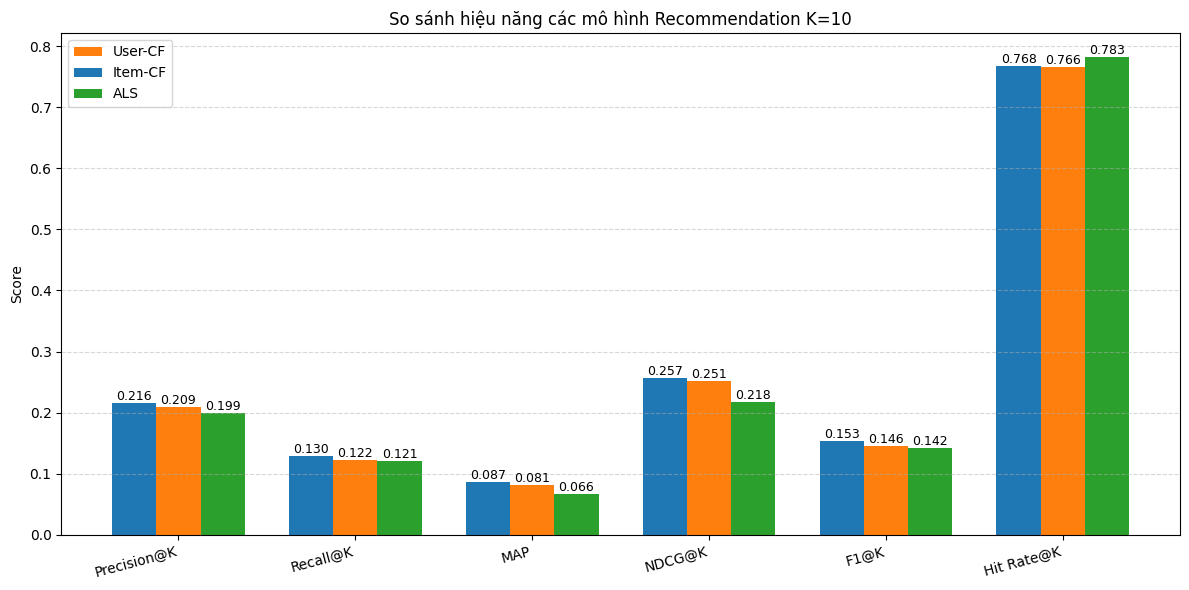

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== INPUT =====
models = ["Item-CF", "User-CF", "ALS"]

metric_names = list(metrics_item_cf.keys())  # ['Precision@K', 'Recall@K', 'MAP', 'NDCG@K', 'F1@K', 'Hit Rate@K']

# Lấy giá trị tương ứng cho từng mô hình
item_vals = [metrics_item_cf[m] for m in metric_names]
user_vals = [metrics_user_cf[m] for m in metric_names]
als_vals  = [metrics_als[m] for m in metric_names]

# ===== PLOT =====
x = np.arange(len(metric_names))  # 0, 1, 2, 3, 4, 5
width = 0.25  # Độ rộng thanh

plt.figure(figsize=(12, 6))  # 6 metrics

bars_user = plt.bar(x,         user_vals, width, label="User-CF", color="#ff7f0e")
bars_item = plt.bar(x - width, item_vals, width, label="Item-CF", color="#1f77b4")
bars_als  = plt.bar(x + width, als_vals,  width, label="ALS",     color="#2ca02c")

# Đặt tên metrics trên trục X
plt.xticks(x, metric_names, rotation=15, ha="right", fontsize=10)

plt.ylabel("Score")
plt.title("So sánh hiệu năng các mô hình Recommendation K=10")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

# ===== ADD VALUE LABELS =====
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars_item)
add_labels(bars_user)
add_labels(bars_als)

plt.tight_layout()
plt.show()